# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 5

### Wstęp

Przedsiębiorstwo zajmujące się produkcją wyrobów mlecznych otrzymało kilka zamówień od klientów. Dane dotyczące cen składników, ich wykorzystania w produktach oraz zamówień zostały przedstawione poniżej.

### Dane

**Ceny składników:**

| Składnik     | Cena (PLN) |
| :---         | ---: |
| Mleko (l)    | 3.5 |
| Cukier (kg)  | 5   |
| Kakao (100g) | 8   |
| Sól (kg)     | 2   |


**Zestawienie składników wykorzystywanych w produktach:**

| Prod.\Skł.| Mleko (l) | Cukier (kg)  | Kakao (100g) | Sól (kg)    |
| :---      |      ---: |         ---: |         ---: |        ---: |
| Masło     | 5         | 0            | 0            | 0           |
| Czekolada | 1         | 0.1          | 5            | 0.01        |
| Ser żółty | 10        | 0            | 0            | 0.05        |
| Twaróg    | 2         | 0            | 0            | 0.1         |


**Zamówienia złożone przez klientów:**

| Klient\Prod.| Masło | Czekolada | Ser żółty | Twaróg |
| :---        |  ---: |      ---: |      ---: |   ---: |
| Klient 1    | 10    | 50        | 5         | 5      |
| Klient 2    | 120   | 90        | 15        | 25     |
| Klient 3    | 0     | 10        | 1         | 1      |


> **Uwaga**: W celu wizualizacji wyników można wykorzystać funkcję `plt.table`.

> Informacja: Przedstawione dane mają charakter poglądowy i nie odwzorowują rzeczywistych uwarunkowań rynkowych.

### Zadanie 1

Z wykorzystaniem operacji macierzowych należy obliczyć odpowiednie wartości i udzielić odpowiedzi na poniższe pytania:

#### A) Jaki jest koszt wyprodukowania każdego z produktów?






 

In [371]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [372]:
ingredients = [["milk (1l)", 3.5], ["sugar (1kg)", 5], ["cocoa powder (100g)", 8], ["salt (1kg)", 2]]
ingredients = pd.DataFrame(ingredients, columns=["ingredient", "price"])
ingredients

,ingredient,price
0,milk (1l),3.5
1,sugar (1kg),5.0
2,cocoa powder (100g),8.0
3,salt (1kg),2.0


In [373]:
products = [["butter",5,0,0,0],["chocolate",1,0.1,5,0.01],["cheese", 10,0,0,0.05],["cottage cheese",2,0,0,0.1]]
products = pd.DataFrame(products, columns=["product", "milk", "sugar", "cocoa powder", "salt"])
products

,product,milk,sugar,cocoa powder,salt
0,butter,5,0.0,0,0.00
1,chocolate,1,0.1,5,0.01
2,cheese,10,0.0,0,0.05
3,cottage cheese,2,0.0,0,0.10


In [374]:
orders = [[10,50,5,5],[120,90,15,25],[0,10,1,1]]
orders = pd.DataFrame(orders, columns=["butter", "chocolate", "cheese", "cottage cheese"])
orders

,butter,chocolate,cheese,cottage cheese
0,10,50,5,5
1,120,90,15,25
2,0,10,1,1


In [375]:
ingredients.shape, products.shape, orders.shape

((4, 2), (4, 5), (3, 4))

In [376]:
i = ingredients["price"].values # convert to numpy array
p = products.drop(columns=["product"]).values
i.shape, p.shape

((4,), (4, 4))

In [377]:
price = p @ i
price

array([17.5 , 44.02, 35.1 ,  7.2 ])

In [378]:
price_df = pd.DataFrame({
    "product": products["product"],
    "price": price
})
price_df

,product,price
0,butter,17.50
1,chocolate,44.02
2,cheese,35.10
3,cottage cheese,7.20


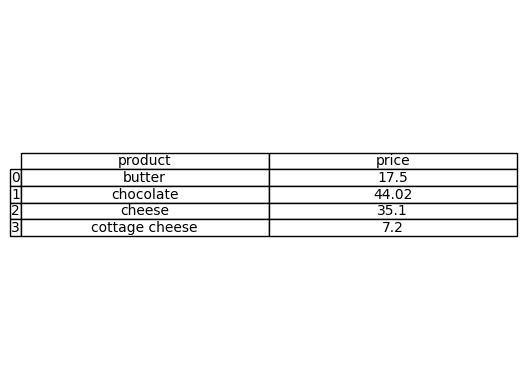

In [379]:
fix, ax = plt.subplots()
ax.axis('off')
pd.plotting.table(ax, price_df, loc='center', cellLoc='center')

#### B) Ile składników zostanie uzytych na realizację zamówień klientów (każdego osobno i łącznie)?



In [380]:
o = orders.values
o.shape, o

((3, 4),
 array([[ 10,  50,   5,   5],
        [120,  90,  15,  25],
        [  0,  10,   1,   1]], dtype=int64))

In [381]:
p.shape, p

((4, 4),
 array([[ 5.  ,  0.  ,  0.  ,  0.  ],
        [ 1.  ,  0.1 ,  5.  ,  0.01],
        [10.  ,  0.  ,  0.  ,  0.05],
        [ 2.  ,  0.  ,  0.  ,  0.1 ]]))

In [382]:
res = o @ p
res

array([[1.60e+02, 5.00e+00, 2.50e+02, 1.25e+00],
       [8.90e+02, 9.00e+00, 4.50e+02, 4.15e+00],
       [2.20e+01, 1.00e+00, 5.00e+01, 2.50e-01]])

In [383]:
res.shape

(3, 4)

In [384]:
ones = np.ones(res.shape[0])
ones.shape, ones

((3,), array([1., 1., 1.]))

In [385]:
res_ = res.T @ ones
res_

array([1072.  ,   15.  ,  750.  ,    5.65])

In [386]:
usage = pd.DataFrame(o @ p , columns = ingredients["ingredient"].values)
usage.loc[len(usage)] = res_
usage.insert(0, "clients", ["client 1", "client 2", "client 3", "sum"])

usage

,clients,milk (1l),sugar (1kg),cocoa powder (100g),salt (1kg)
0,client 1,160.0,5.0,250.0,1.25
1,client 2,890.0,9.0,450.0,4.15
2,client 3,22.0,1.0,50.0,0.25
3,sum,1072.0,15.0,750.0,5.65


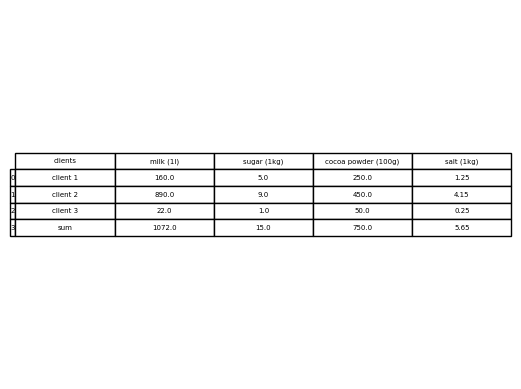

In [387]:
fix, ax = plt.subplots()
ax.axis('off')
pd.plotting.table(ax, usage, loc='center', cellLoc='center')

#### C) Zakładając marżę $30\%$ (pomijając wszystkie inne czynniki), ile klienci będą musieli zapłacić za zrealizowanie zamówienia?



In [388]:
c = usage.drop(columns=["clients"]).values[:-1] # without sum
c,i

(array([[1.60e+02, 5.00e+00, 2.50e+02, 1.25e+00],
        [8.90e+02, 9.00e+00, 4.50e+02, 4.15e+00],
        [2.20e+01, 1.00e+00, 5.00e+01, 2.50e-01]]),
 array([3.5, 5. , 8. , 2. ]))

In [389]:
c.shape, i.shape

((3, 4), (4,))

In [390]:
tax = np.array([1.3]*c.shape[0])
tax, tax.shape

(array([1.3, 1.3, 1.3]), (3,))

In [391]:
cost = c @ i 
cost.shape, cost

((3,), array([2587.5, 6768.3,  482.5]))

In [392]:
I = np.eye(3)
I

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [393]:
test = np.c_[cost, cost, cost]
test.shape
test = test @ I 
test

array([[2587.5, 2587.5, 2587.5],
       [6768.3, 6768.3, 6768.3],
       [ 482.5,  482.5,  482.5]])

In [394]:
total_cost = test @ np.array([1.3, 0, 0])
total_cost.shape, total_cost

((3,), array([3363.75, 8798.79,  627.25]))

In [395]:
total_cost_ = pd.DataFrame({
    "clients": ["client1", "client2", "client3"],
    "total cost": total_cost
})
total_cost_

,clients,total cost
0,client1,3363.75
1,client2,8798.79
2,client3,627.25


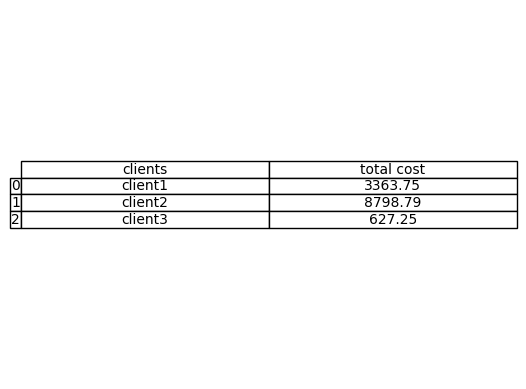

In [409]:
fix, ax = plt.subplots()
ax.axis('off')
pd.plotting.table(ax, total_cost_, loc='center', cellLoc='center')

#### D) Jaki jest łączny koszt składników jakie należy zamówić, aby zrealizować wszystkie zamówienia klientów?




In [397]:
cost = c @ i 
s = cost @ np.array([1]*len(cost))
s

9838.3

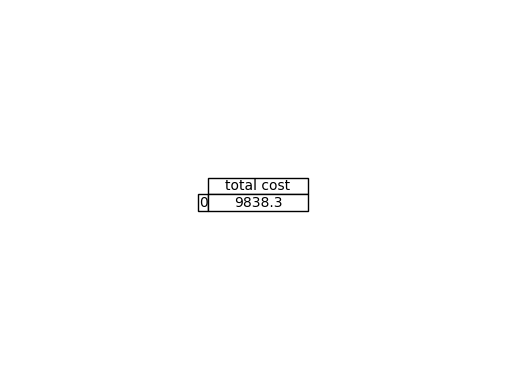

In [398]:
df = pd.DataFrame([s], columns=["total cost"])
fix, ax = plt.subplots()
ax.axis('off')
pd.plotting.table(ax, df, loc='center', cellLoc='center', colWidths=list([.2]))

### Zadanie 2

Należy zaimplementować skrypt, który przyjmuje dwie macierze $A$ oraz $B$, a następnie wypisuje szczegółowe operacje wykonywane podczas ich mnożenia.

**Przykład:**

Dane wejściowe:

\begin{equation}
A = \begin{pmatrix}
1 & 2 & 1\\
4 & 4 & 5\\
6 & 7 & 7
\end{pmatrix}, 
 B = \begin{pmatrix}
-7 & -7 & 6\\
2 & 1 & -1\\
4 & 5 & -4
\end{pmatrix}
\end{equation}

Oczekiwany wynik:

```
C[0, 0] = 1 * (-7) + 2 * 2 + 1 * 4 = 1
C[0, 1] = 1 * (-7) + 2 * 1 + 1 * 5 = 0
C[0, 2] = 1 * 6 + 2 * (-1) + 1 * (-4) = 0
C[1, 0] = 4 * (-7) + 4 * 2 + 5 * 4 = 0
C[1, 1] = 4 * (-7) + 4 * 1 + 5 * 5 = 1
C[1, 2] = 4 * 6 + 4 * (-1) + 5 * (-4) = 0
C[2, 0] = 6 * (-7) + 7 * 2 + 7 * 4 = 0
C[2, 1] = 6 * (-7) + 7 * 1 + 7 * 5 = 0
C[2, 2] = 6 * 6 + 7 * (-1) + 7 * (-4) = 1

[[1 0 0]
 [0 1 0]
 [0 0 1]]
```



In [ ]:
def specific_mul(A, B):
    n = len(A) # num of rows in A
    m = len(A[0]) # num of cols in A/num of rows in B
    C = [[0]*m for _ in range(n)]
    for i in range(n): # for each row in A
        for j in range(m): # for each col in A / row in B
            print(f"C[{i},{j}] = ", end="")
            total = 0
            for k in range(m): 
                a = A[i][k]
                b = B[k][j]
                total += a * b
                str_a = str(a) if a > 0 else ("(" + str(a) + ")")
                str_b = str(b) if b > 0 else ("(" + str(b) + ")")
                if k + 1 == m:
                    print(f"{str_a} * {str_b}", end="")
                else:
                    print(f"{str_a} * {str_b}", end=" + ")
                
            print(f" = {total}")
            C[i][j] = total
            
    return np.array(C)
            

A = [[1,2,1],[4,4,5],[6,7,7]]
B = [[-7,-7,6],[2,1,-1],[4,5,-4]]
C = specific_mul(A, B)
C

C[0,0] = 1 * (-7) + 2 * 2 + 1 * 4 = 1
C[0,1] = 1 * (-7) + 2 * 1 + 1 * 5 = 0
C[0,2] = 1 * 6 + 2 * (-1) + 1 * (-4) = 0
C[1,0] = 4 * (-7) + 4 * 2 + 5 * 4 = 0
C[1,1] = 4 * (-7) + 4 * 1 + 5 * 5 = 1
C[1,2] = 4 * 6 + 4 * (-1) + 5 * (-4) = 0
C[2,0] = 6 * (-7) + 7 * 2 + 7 * 4 = 0
C[2,1] = 6 * (-7) + 7 * 1 + 7 * 5 = 0
C[2,2] = 6 * 6 + 7 * (-1) + 7 * (-4) = 1


array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])